<a href="https://colab.research.google.com/github/JingyuHe02/COMP3132/blob/main/LabWeek10/LabWeek10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ## Lab - Week 10 - Dropout

### Ways to reduce overfitting in neural networks
 - Getting more training data
 - Reducing the capacity of the network (last week's lab)
 - Adding weight regularization (last week's lab)
 - Adding dropout (the subject for this week)
 - Using transfer learning

### Typical training and validation loss over time
![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*0VWDpLIRcMTssDf-zyOR4w.jpeg)

## Dropout Regularization

**Dropout** is a regularization technique that involves randomly "dropping out" (setting to zero) a subset of a layer's output features during training.

For example, if a layer would normally return the vector `[0.2, 0.5, 1.3, 0.8, 1.1]` for a specific input, applying dropout might result in `[0, 0.5, 1.3, 0, 1.1]`. The **dropout rate** defines the fraction of features zeroed out and typically ranges between 0.2 and 0.5.

At test time, no units are dropped. To compensate for the fact that all neurons are now active (unlike during training), the layer’s output values are scaled down by a factor equal to the dropout rate. This ensures that the expected sum of the inputs to the next layer remains consistent between training and inference.


![dropout](https://cdn-images-1.medium.com/max/1600/1*iWQzxhVlvadk6VAJjsgXgg.png)

In Keras you can introduce dropout in a network via the `Dropout` layer, which gets applied to the output of layer right before it, e.g.:
```python
model.add(layers.Dropout(0.5))
```

### Part 1: Load and Prepare Data - IMDB dataset

In [1]:
from keras import models
from keras import layers
from keras.datasets import imdb
import numpy as np

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
      for j in sequence:
        results[i, j] += 1
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
# Our vectorized labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**As a routine, perform a sanity check on the dataset to understand the shape of the train and test inputs and outputs, and print out a sample of the data.**

In [2]:
# Sanity check
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nFirst training review vector length:", len(x_train[0]))
print("First 20 values of first review vector:", x_train[0][:20])
print("First training label:", y_train[0])

print("\nUnique labels in training set:", np.unique(y_train))
print("Number of training samples:", len(x_train))
print("Number of test samples:", len(x_test))

x_train shape: (25000, 10000)
x_test shape: (25000, 10000)
y_train shape: (25000,)
y_test shape: (25000,)

First training review vector length: 10000
First 20 values of first review vector: [ 0.  1.  6.  0. 15.  9.  3.  2.  3.  1.  0.  0.  6.  3.  3.  4. 11.  3.
  3.  2.]
First training label: 1.0

Unique labels in training set: [0. 1.]
Number of training samples: 25000
Number of test samples: 25000


### Part 2: Build a Simple Neural Network Model
Objective: Create a basic neural network model using Keras.

**Questions**
- What type of classification problem are we solving?
- How many neurons should there be in the output layer?
- What should be the activation function of the output layer?
- What loss function should be used?
- What activation function should be used on the hidden layers?


Build a sequential model with one dense layer with 8 units and train it for 20 epochs.

Complete the code below:

In [3]:
# Build a simple baseline model
model = models.Sequential()
model.add(layers.Dense(8, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │        80,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,017 (312.57 KB)

 Trainable params: 80,017 (312.57 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Train the model
hist_a = model.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))

# Evaluate the model
evaluation_results = model.evaluate(x_test, y_test)
print("Test accuracy:", evaluation_results[1])

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.7916 - loss: 0.5064 - val_accuracy: 0.8517 - val_loss: 0.4152
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8929 - loss: 0.3371 - val_accuracy: 0.8744 - val_loss: 0.3485
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9116 - loss: 0.2718 - val_accuracy: 0.8860 - val_loss: 0.3076
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9192 - loss: 0.2382 - val_accuracy: 0.8886 - val_loss: 0.2902
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9276 - loss: 0.2129 - val_accuracy: 0.8900 - val_loss: 0.2844
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9354 - loss: 0.1960 - val_accuracy: 0.8880 - val_loss: 0.2869
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9401 - loss: 0.1817 - val_accuracy: 0.8833 - val_loss: 0.2997
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9443 - loss: 0.1685 - val_accuracy: 0.8871 - v

### Part 3: Visualize Training and Validation Performance

The function below can be used later to plot the loss and accuracy from the model training history

In [6]:
# Helper function

import matplotlib.pyplot as plt
# colors will be used to plot the different models below
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

def plot_history(history, color='blue', prefix=""):
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)

    # Make a figure with two subplots side by side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)

    # Plot the loss
    plt.plot(epochs, loss_values, "o",  color=color, label=prefix + " Training loss")
    plt.plot(epochs, val_loss_values, color=color, label=prefix + " Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(framealpha=0.5)
    plt.grid()

    # Plot the accuracy
    plt.subplot(1, 2, 2)
    acc_values = history_dict["acc"]
    val_acc_values = history_dict["val_acc"]
    # Skip plotting the training accuracy, it makes the plot harder to read
    # plt.plot(epochs, acc_values, "o", color=color , label=prefix + " Training accuracy")
    plt.plot(epochs, val_acc_values, color=color, label=prefix + " Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(framealpha=0.5)
    plt.grid()

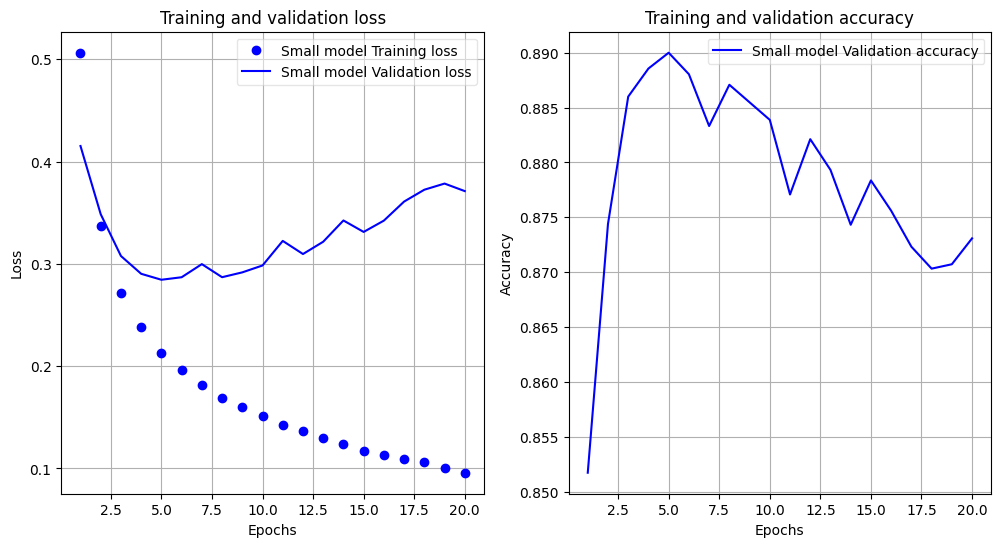

In [8]:
import matplotlib.pyplot as plt

# Helper function - Modified to use 'accuracy' and 'val_accuracy'
# colors will be used to plot the different models below
# Assuming 'colors' variable is already defined and available from previous cell execution

def plot_history(history, color='blue', prefix=""):
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)

    # Make a figure with two subplots side by side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)

    # Plot the loss
    plt.plot(epochs, loss_values, "o",  color=color, label=prefix + " Training loss")
    plt.plot(epochs, val_loss_values, color=color, label=prefix + " Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(framealpha=0.5)
    plt.grid()

    # Plot the accuracy
    plt.subplot(1, 2, 2)
    acc_values = history_dict["accuracy"] # Changed from 'acc'
    val_acc_values = history_dict["val_accuracy"] # Changed from 'val_acc'
    # Skip plotting the training accuracy, it makes the plot harder to read
    # plt.plot(epochs, acc_values, "o", color=color , label=prefix + " Training accuracy")
    plt.plot(epochs, val_acc_values, color=color, label=prefix + " Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(framealpha=0.5)
    plt.grid()

# Using the plotting function
plot_history(hist_a, color='blue', prefix="Small model")

### Part 4: Add Dropout Regularization
Objective: Experiment with dropout layers in the model.

**Instructions:**
1. Add another hidden layer with 8 units
1. Add dropout layers after each hidden layer with a dropout rate of 0.3.
1. Compile the model.
1. Train the model and observe the changes in accuracy.

Complete the code below:

In [9]:
# Build a model with 30% Dropout
drp_model = models.Sequential()
drp_model.add(layers.Dense(8, activation='relu', input_shape=(10000,)))
drp_model.add(layers.Dropout(0.3))
drp_model.add(layers.Dense(1, activation='sigmoid'))

drp_model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

drp_model.summary()

drp_history = drp_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test)
)

drp_results = drp_model.evaluate(x_test, y_test)
print("Dropout 0.3 test loss, test accuracy:", drp_results)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │        80,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,017 (312.57 KB)

 Trainable params: 80,017 (312.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.7346 - loss: 0.5483 - val_accuracy: 0.8613 - val_loss: 0.4242
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - accuracy: 0.8513 - loss: 0.3977 - val_accuracy: 0.8788 - val_loss: 0.3539
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8819 - loss: 0.3322 - val_accuracy: 0.8860 - val_loss: 0.3201
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8977 - loss: 0.2919 - val_accuracy: 0.8892 - val_loss: 0.3020
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9063 - loss: 0.2653 - val_accuracy: 0.8891 - val_loss: 0.2894
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9178 - loss: 0.2378 - val_accuracy: 0.8896 - val_loss: 0.2844
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9245 - loss: 0.2232 - val_accuracy: 0.8889 - val_loss: 0.2814
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9296 - loss: 0.2052 - val_accuracy: 0.8885 - 

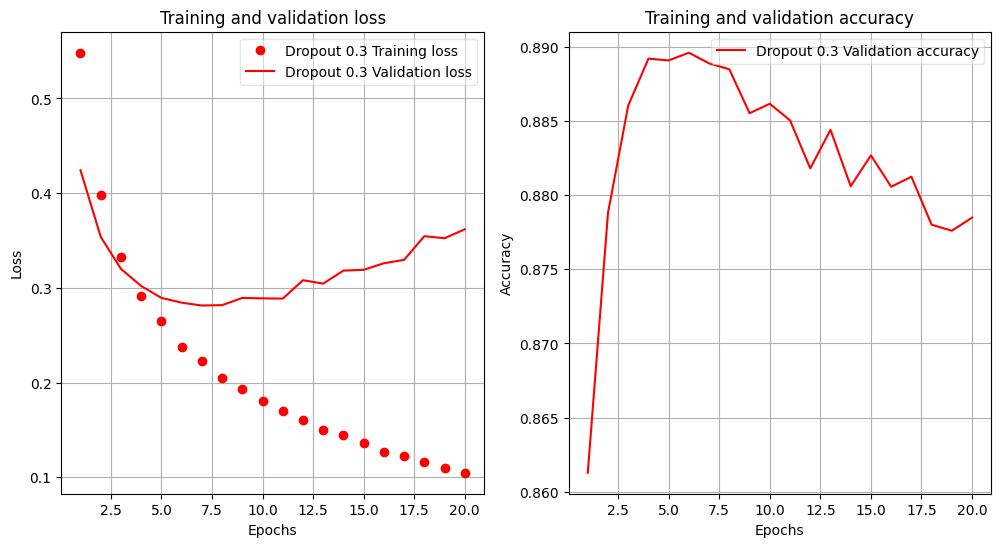

In [10]:
# Plot training history
plot_history(drp_history, color='red', prefix="Dropout 0.3")

### Part 5: Test Different Dropout Rates
Objective: Compare the model's performance with varying dropout rates.

**Instructions:**
1. Write a loop to create and train models with dropout rates of `[0, 0.2, 0.3, 0.4, 0.5]`.
2. For each model, record the history to plot it later


Complete the code below:

In [11]:
# Try different dropout rates
rates = [0, 0.2, 0.3, 0.4, 0.5]
hists = []

for rate in rates:
    temp_model = models.Sequential()
    temp_model.add(layers.Dense(8, activation='relu', input_shape=(10000,)))
    if rate > 0:
        temp_model.add(layers.Dropout(rate))
    temp_model.add(layers.Dense(1, activation='sigmoid'))

    temp_model.compile(optimizer='rmsprop',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

    print(f"\nTraining model with dropout rate = {rate}")
    hist = temp_model.fit(
        x_train,
        y_train,
        epochs=20,
        batch_size=512,
        validation_data=(x_test, y_test),
        verbose=1
    )
    hists.append(hist)


Training model with dropout rate = 0
Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7811 - loss: 0.5120 - val_accuracy: 0.8668 - val_loss: 0.3983
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8923 - loss: 0.3302 - val_accuracy: 0.8780 - val_loss: 0.3328
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9098 - loss: 0.2665 - val_accuracy: 0.8879 - val_loss: 0.3017
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9214 - loss: 0.2311 - val_accuracy: 0.8841 - val_loss: 0.2977
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9304 - loss: 0.2076 - val_accuracy: 0.8833 - val_loss: 0.3005
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9364 - loss: 0.1897 - val_accuracy: 0.8858 - val_loss: 0.2927
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9421 - loss: 0.1761 - val_accuracy: 0.8880 - val_loss: 0.2852
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9453 - l

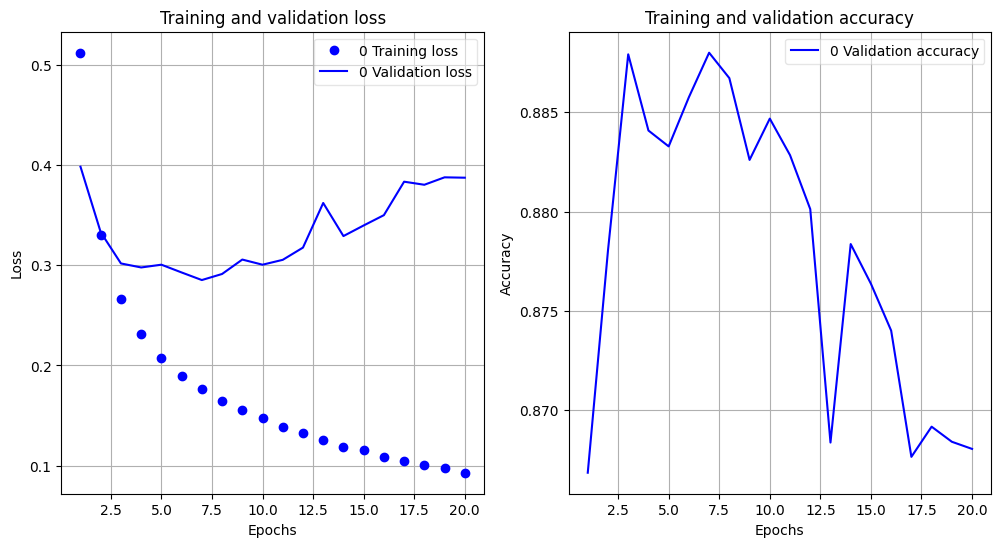

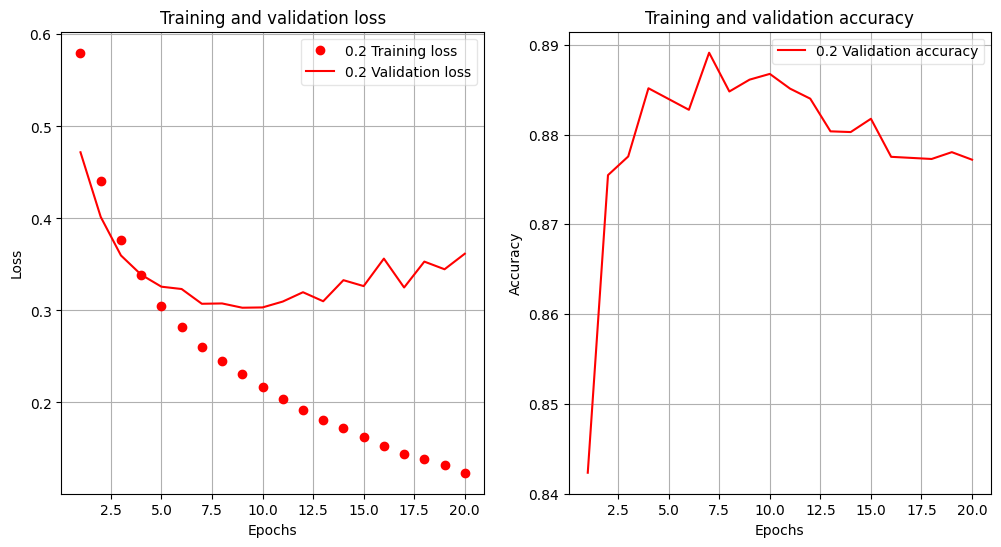

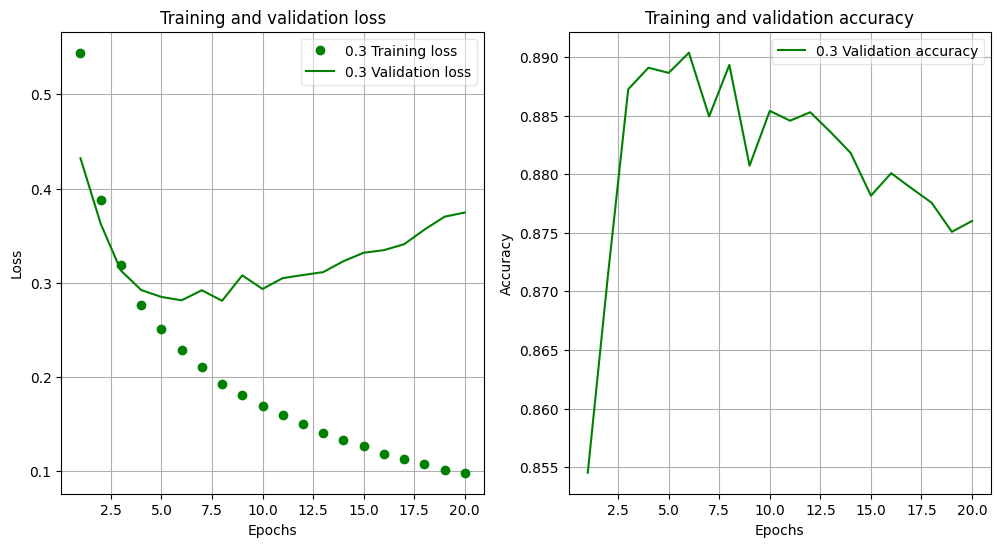

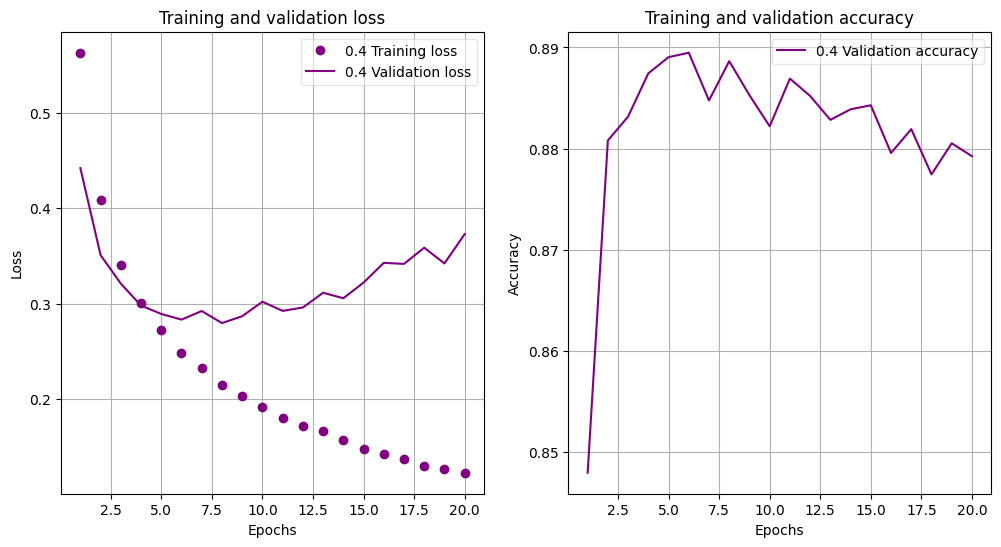

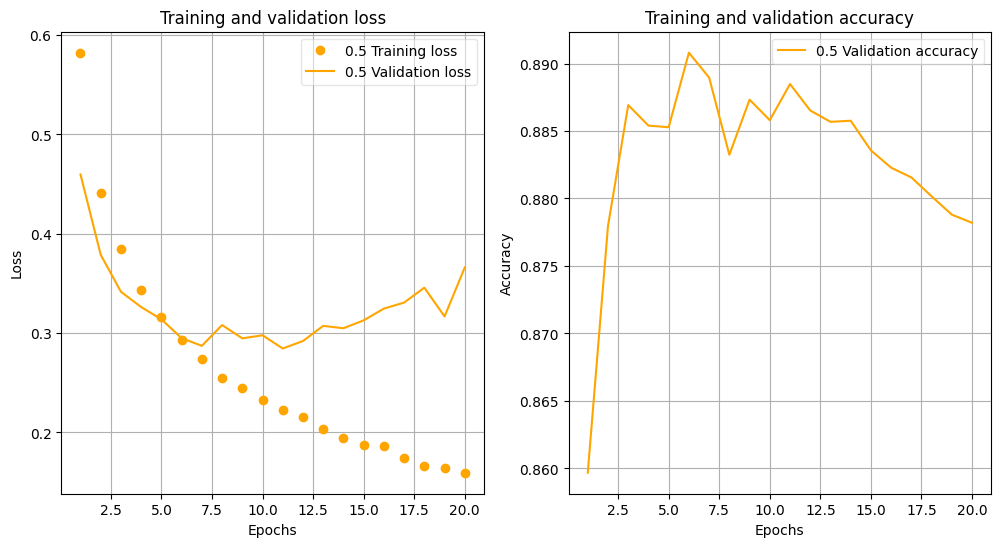

In [12]:
for i, hist in enumerate(hists):
    plot_history(hist, colors[i], prefix=str(rates[i]))

### Part 6: Experiment with dropout location
Objective: Compare the model's performance with dropout placed after different layers

**Instructions:**
Create 3 models with a single dropout "layer" placed:
1. Before the first dense layer only
2. After the first dense layer only
3. After the second dense layer only



Complete the code below:

In [13]:
hists_b = []  # append the training history of 3 cases mentioned above
rate = 0.4

# 1) Dropout before the 1st Dense layer
model_before = models.Sequential()
model_before.add(layers.Dropout(rate, input_shape=(10000,)))
model_before.add(layers.Dense(8, activation='relu'))
model_before.add(layers.Dense(1, activation='sigmoid'))
model_before.compile(optimizer='rmsprop',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])
hist_before = model_before.fit(
    x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test)
)
hists_b.append(hist_before)

# 2) Dropout after the 1st Dense layer
model_after_1 = models.Sequential()
model_after_1.add(layers.Dense(8, activation='relu', input_shape=(10000,)))
model_after_1.add(layers.Dropout(rate))
model_after_1.add(layers.Dense(1, activation='sigmoid'))
model_after_1.compile(optimizer='rmsprop',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
hist_after_1 = model_after_1.fit(
    x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test)
)
hists_b.append(hist_after_1)

# 3) Dropout after a 2nd Dense layer
model_after_2 = models.Sequential()
model_after_2.add(layers.Dense(8, activation='relu', input_shape=(10000,)))
model_after_2.add(layers.Dense(8, activation='relu'))
model_after_2.add(layers.Dropout(rate))
model_after_2.add(layers.Dense(1, activation='sigmoid'))
model_after_2.compile(optimizer='rmsprop',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
hist_after_2 = model_after_2.fit(
    x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test)
)
hists_b.append(hist_after_2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.7436 - loss: 0.5499 - val_accuracy: 0.8577 - val_loss: 0.4307
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.8529 - loss: 0.3938 - val_accuracy: 0.8814 - val_loss: 0.3528
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.8709 - loss: 0.3386 - val_accuracy: 0.8864 - val_loss: 0.3269
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.8818 - loss: 0.3088 - val_accuracy: 0.8856 - val_loss: 0.3170
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.8896 - loss: 0.2926 - val_accuracy: 0.8886 - val_loss: 0.2982
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.8884 - loss: 0.2838 - val_accuracy: 0.8918 - val_loss: 0.2911
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.8927 - loss: 0.2779 - val_accuracy: 0.8919 - val_loss: 0.2898
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.8956 - loss: 0.2655 - val_accuracy: 0.8852 -

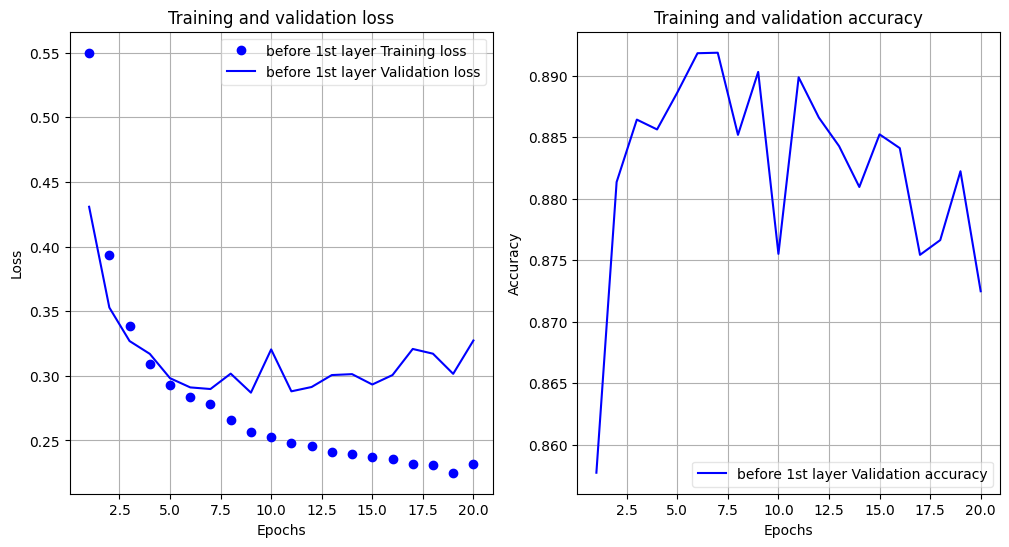

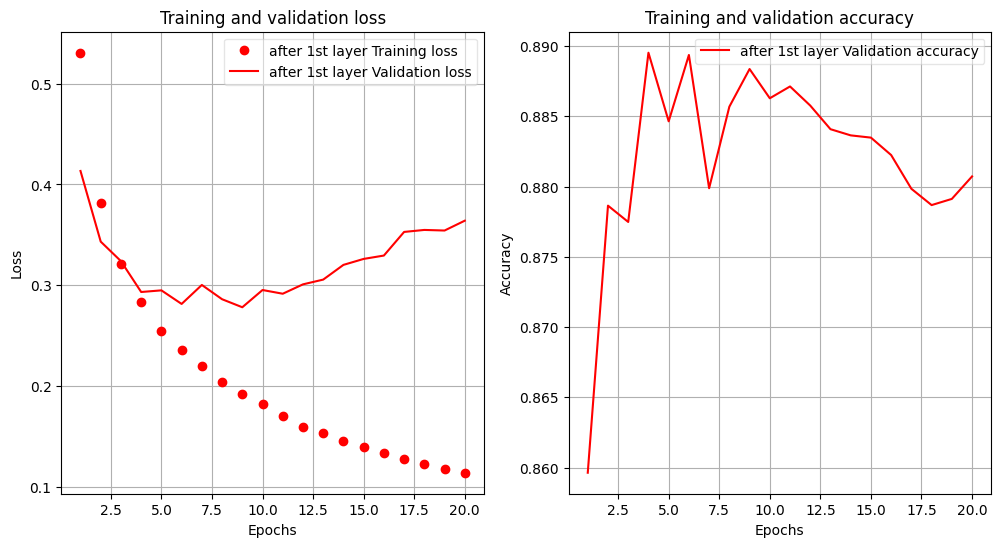

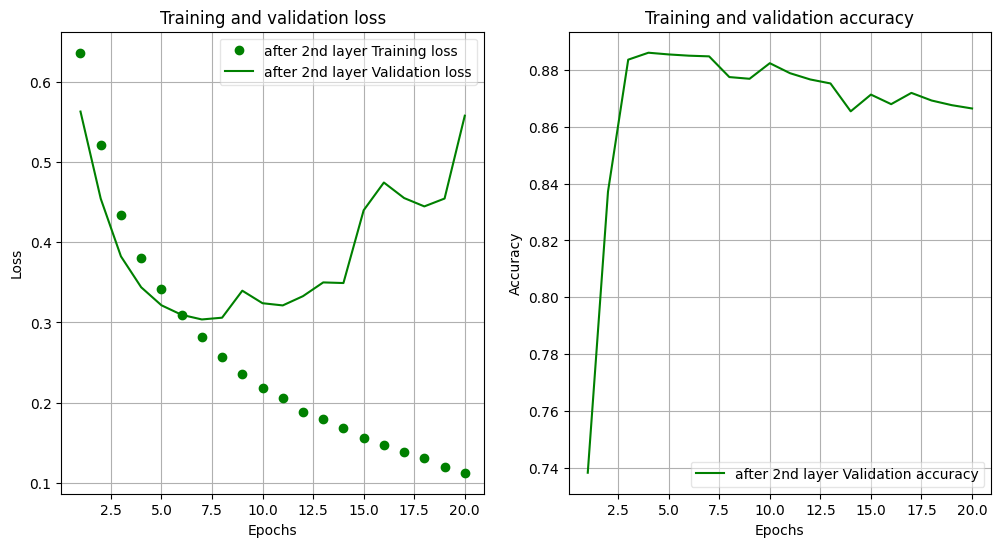

In [14]:
prefixes = ['before 1st layer', 'after 1st layer', 'after 2nd layer']
for i, hist in enumerate(hists_b):
    plot_history(hist, colors[i], prefix=prefixes[i])